# Assignment 1

## Extract webpage data given the url

Create a Python script that performs basic web scraping on a page to extract all the information into text and returns it as a string. String should not contain tags.

In [4]:
def parse_web_page(url):
    """
    Fetch the content of the given web page.

    Args:
        url (str): The URL of the web page to fetch.

    Returns:
        str: The content of the page as a string.

    Raises:
        HTTPError: If the HTTP request returned an unsuccessful status code.
    """
    import requests
    from bs4 import BeautifulSoup

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    return soup.get_text(" ", strip=True) 

"""
    Replace the following links with links you wish to parse for this assignemnt.
"""
# print(parse_web_page('https://fmi.chnu.edu.ua/')[:255])
print(parse_web_page('https://en.wikipedia.org/wiki/Web_scraping')[:255])

Web scraping - Wikipedia Jump to content Main menu Main menu move to sidebar hide Navigation Main page Contents Current events Random article About Wikipedia Contact us Contribute Help Learn to edit Community portal Recent changes Upload file Special page


## Get data from the API

Create a python script that performs basic request to API endpoint and saves that data to a JSON file result.json.

In [6]:
def parse_api(api_url):
    """
    Fetch the data of the given API endpoint and save it to result.json.

    Args:
        api_url (str): The URL of the API endpoint.

    Returns:
        None.

    Raises:
        HTTPError: If the HTTP request returned an unsuccessful status code.
    """
    import requests
    import json

    response = requests.get(api_url)
    response.raise_for_status()

    data = response.json()

    with open("result.json", "w", encoding="utf-8") as file:
     json.dump(data, file, ensure_ascii=False, indent=4)
"""
    Replace the following api with api you wish to parse for this assignemnt.
    You can use https://free-apis.github.io/#/ or any other available api endpoint you like.
"""
parse_api('https://api.github.com/')

## Parse the json file

Parse the `weather.json` file and return weather data for a specific date, that is given as a parameter. Return the data as an array.

In [9]:
def parse_json(date):
    """
    Parse the data from weather.json file and return weather data for a given date.

    Args:
        date (str): The date for which we look up the weather.

    Returns:
        list: a list of weather data for a given date.
    """
    import json

    with open("resources/weather.json", "r", encoding="utf-8") as file:
        data = json.load(file)

    result = []

    for item in data["daily"]:
        if item.get("date") == date:
            result.append(item)

    return result
    
target_date = '2024-08-19'
print(parse_json(target_date))

[{'date': '2024-08-19', 'max_temperature': 30.0, 'min_temperature': 21.0, 'precipitation': 5.0, 'wind_speed': 10.0, 'humidity': 70, 'weather_description': 'Light rain'}]


## Parse the csv file

Parse the `weather.csv` file and return weather data for a specific date, that is given as a parameter. Return the data as an array.

In [18]:
def parse_csv(date): 
    import csv
    result = []

    with open("resources/weather.csv", "r", encoding="utf-8") as file:
        reader = csv.DictReader(file)

        for row in reader:
            if row["CET"] == date:
                result.append(row)

    return result
target_date = '1997-5-22' 
print(parse_csv(target_date))

[{'CET': '1997-5-22', 'Max TemperatureC': '25', 'Mean TemperatureC': '18', 'Min TemperatureC': '10', 'Dew PointC': '11', 'MeanDew PointC': '8', 'Min DewpointC': '6', 'Max Humidity': '88', ' Mean Humidity': '54', ' Min Humidity': '34', ' Max Sea Level PressurehPa': '1017', ' Mean Sea Level PressurehPa': '1015', ' Min Sea Level PressurehPa': '1012', ' Max VisibilityKm': '10', ' Mean VisibilityKm': '10', ' Min VisibilitykM': '10', ' Max Wind SpeedKm/h': '11', ' Mean Wind SpeedKm/h': '3', ' Max Gust SpeedKm/h': '', 'Precipitationmm': '0.00', ' CloudCover': '3', ' Events': '', 'WindDirDegrees': '277'}]


## Visualize data

Visualize the weather.csv data using matplotlib. Choose your own approach to data visualization. Save the results (as .png, .webp files etc., your choise) in this repository.

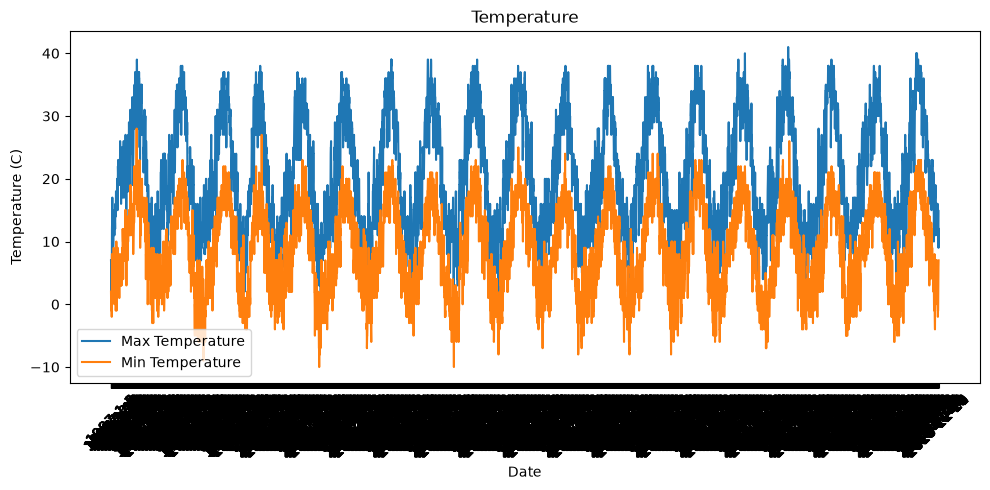

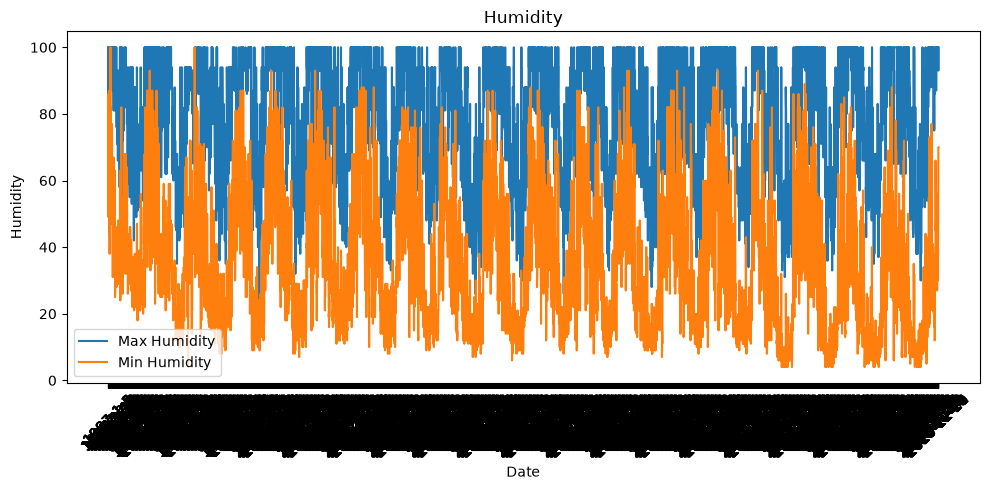

In [3]:
def visualize_data():
    """
    Parse the data from weather.csv file and visualize it using Matplotlib. Use more then one visualization. 
    Save the results in the repository.

    Args:
        None: None.

    Returns:
        None: None.
    """
    import pandas as pd 
    import matplotlib.pyplot as plt
    
    data = pd.read_csv("resources/weather.csv")
    # Графік 1 — температура
    plt.figure(figsize=(10, 5)) 
    plt.plot(data["CET"], data["Max TemperatureC"], label="Max Temperature") 
    plt.plot(data["CET"], data["Min TemperatureC"], label="Min Temperature") 
    plt.xlabel("Date") 
    plt.ylabel("Temperature (C)") 
    plt.title("Temperature") 
    plt.legend() 
    plt.xticks(rotation=45) 
    plt.tight_layout() 
    plt.savefig("temperature.png") 
    plt.show()
 
    #Графік 2 — вологість
    plt.figure(figsize=(10, 5)) 
    plt.plot(data["CET"], data["Max Humidity"], label="Max Humidity") 
    plt.plot(data["CET"], data[" Min Humidity"], label="Min Humidity") 
    plt.xlabel("Date") 
    plt.ylabel("Humidity") 
    plt.title("Humidity") 
    plt.legend() 
    plt.xticks(rotation=45) 
    plt.tight_layout() 
    plt.savefig("humidity.png") 
    plt.show()
  
visualize_data()

## Data imputation and normalization.

Download kaggle dataset with incomplete/missing data, and try data imputation techniques (mean, median, mode, knn) on that data. Normalize the data with best option for each dataset (minmax, z-score, robust). Visualize the data (choose your own approach to data visualization).

Dataset options:
- Different Types of Missing Data (by Suryaprabha19) https://www.kaggle.com/datasets/suryaprabha19/different-types-of-missing-data
- Retail Product Dataset with Missing Values (by Himel Sarder) https://www.kaggle.com/datasets/himelsarder/retail-product-dataset-with-missing-values
- Data Cleaning - Feature Imputation (by 
Mr.Machine) https://www.kaggle.com/datasets/ilayaraja07/data-cleaning-feature-imputation
- BI intro to data cleaning eda and machine learning (by Walekhwa Tambiti Leo Philip) https://www.kaggle.com/datasets/walekhwatlphilip/intro-to-data-cleaning-eda-and-machine-learning

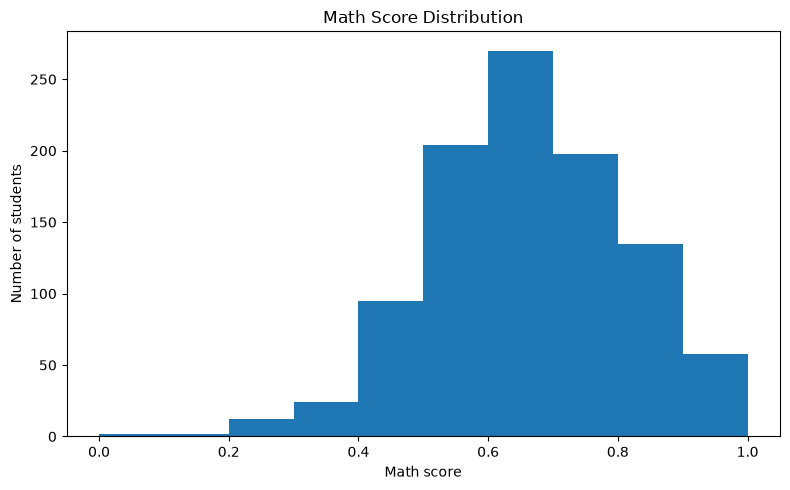

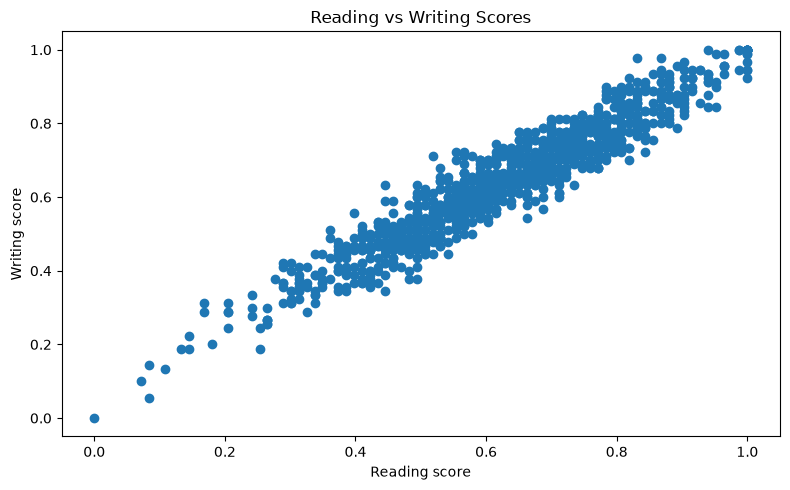

In [6]:
# pip install "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

def load_dataset(url, csv_file):
    """
    Load the dataset from Kaggle using kagglehub.

    Args:
        url (str): The URL of the Kaggle dataset.
        csv_file (str): The name of the CSV file to load from the dataset.
    Returns:
        pd.DataFrame: The loaded dataset as a pandas DataFrame.
    """
    df = kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            url,
            csv_file
        )
    return df

def impute_data(df):
    """
    Parse the data from file and impute missing values using your preferred method.

    Args:
        df (pd.DataFrame): The dataset as a pandas DataFrame.

    Returns:
        pd.DataFrame: The dataset with imputed values.
    """
    numeric_columns = df.select_dtypes(include="number").columns
    categorical_columns = df.select_dtypes(exclude="number").columns

    for column in numeric_columns:
        df[column] = df[column].fillna(df[column].median())

    for column in categorical_columns:
        df[column] = df[column].fillna(df[column].mode()[0])

    return df

def normalize_data(df):
    """
    Normalize the data using your preferred method.

    Args:
        df (pd.DataFrame): The dataset as a pandas DataFrame.

    Returns:
        pd.DataFrame: The dataset with normalized values.
    """
    numeric_columns = df.select_dtypes(include="number").columns
    for column in numeric_columns: 
        min_value = df[column].min() 
        max_value = df[column].max()
        
        df[column] = (df[column] - min_value) / (max_value - min_value)
    return df

def visualize_data(df):
    """
    Visualize the data using Matplotlib. Use more then one visualization. 
    Save the results in the repository.

    Args:
        df (pd.DataFrame): The dataset as a pandas DataFrame.

    Returns:
        None: None.
    """
    import matplotlib.pyplot as plt
    #Графік 1 — гістограма оцінок з математики
    plt.figure(figsize=(8, 5)) 
    plt.hist(df["math score"], bins=10) 
    plt.xlabel("Math score") 
    plt.ylabel("Number of students") 
    plt.title("Math Score Distribution") 
    plt.tight_layout() 
    plt.savefig("math_score_distribution.png") 
    plt.show()
    
    #Графік 2 — залежність Reading та Writing
    plt.figure(figsize=(8, 5)) 
    plt.scatter(df["reading score"], df["writing score"]) 
    plt.xlabel("Reading score") 
    plt.ylabel("Writing score") 
    plt.title("Reading vs Writing Scores") 
    plt.tight_layout() 
    plt.savefig("reading_writing_scores.png") 
    plt.show()
    
    return None

df = load_dataset('ilayaraja07/data-cleaning-feature-imputation', 'Students_Performance_knn.csv')
df = impute_data(df)
df = normalize_data(df)
visualize_data(df)